<a href="https://colab.research.google.com/github/HeidiTan0179/ADS1002_SALES_GROUP1/blob/Current_Progress/ADS1002_Group_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group 1 Rossman Drugstore Sales**

### **Group members**
- Harshini I. Thiagerajan - (36063592)
- Wenqi Yang - (35279850)
- Christy Lee Qiu Yi - (34475729)
- Heidi Swee Lin Tan - (36391158)

# **Research Question : What drives success? Unpacking the key factors behind Rossmann Drugstore sales performance.**



## **PROJECT PROGRESS:**

## **30 July 2025**
- A repository in GitHub created by **Heidi Swee Lin Tan**.
- WhatsApp group created for easier communication among group members
- Dataset uploaded and shared among group members  
- Initial data inspection by all members  
- Variable allocation:
  - **Wenqi**: `DayofWeek`, `Sales`
  - **Harshini**: `Promo`, `Sales`, `Customers`, `Date`, `DayofWeek`
  - **Christy**: `Sales`, `Customers`
  - **Heidi**: `Date`, `Sales`

## **6 August 2025**
- A Google Colab file is created to collaborate all work progress together
- Exploratory data analysis done by **Harshini**
- Data visualization techniques discussed as a group

## **13 August 2025**
- Project background information done by **Christy**
- Draft of individual sections started by all members
- First internal deadline to complete each member's drafting

## **20 August 2025**
- Each team member improved their respective parts based on feedback given

## **27 August 2025**
- Regression model discussion and drafting by **Harshini** and **Heidi Tan**
- **Wenqi** and **Christy** improve their respective parts based on given feedback

## **5 September 2025**
- Linear regression finalisation by **Heidi Tan** and **Harshini**
- Group presentation slides were created

## **10 September 2025**
- Mock presentation session during class

## **17 September 2025**
- Each member was assigned a data modelling task
  - Handling Time Series Data - **Heidi**
  - Multivariate Linear Regression - **Harshini**
  - Logistic Regression - **Christy**
  - Decision Trees - **Wenqi Yang**

## **11 October 2025**
- Presentation slides were finalised

## **PROJECT BACKGROUND INFORMATION**
As Rossman operates over 3000 drugstores across 7 countries, demand forecasting plays an important role in ensuring ideal sales performance. Understanding the key factors that influence sales performance is crucial for involved stakeholders.

This project aims to investigate the many factors that affect Rossman store sales. Each group member explores and identifies variables or trends, such as promotions and store-specific characteristics.

## **EXPLORATORY DATA ANALYSIS**
## **PART 1: IMPORTING DATA AND INITIAL OVERVIEW OF DATASET**

The dataset is sourced from [Kaggle](https://www.kaggle.com/c/rossmann-store-sales/data). It is the Rossman Train dataset. The data dictionary is summarized below;

Store: A unique ID for each store

DayOfWeek: Day of the week. (1=Monday, 7=Sunday)

Date: The date on a given day

Sales: The turnover for any given day

Customers The number of customers on a given day

Open: An indicator for whether the store was open. 0 = closed, 1 = open.

Promo: Indicates whether a store is running a promo

StateHoliday: Indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None

SchoolHoliday: Indicates if the (Store, Date) was affected by the closure of public schools

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from scipy.stats import pearsonr
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Rossmann_train.csv to Rossmann_train.csv


In [3]:
train_df = pd.read_csv("Rossmann_train.csv")

#### An initial first look at the dataset

In [4]:
train_df.shape

(1017209, 9)

In [5]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
train_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


### Preliminary/Initial Observations
The Rossman train dataset have ***1017209 observations*** in ***9 variables***.

Looking at the first five and last five rows of the data tells us that the dataset has a mix of continuous and categorical data in it.

In [7]:
#Get the column names
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

#### Initial Observations (continued)
All the variable has no space between the words. Hence, no rename is needed.

In [8]:
#Show data information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


#### Initial Observations (continued)

Based from the `info()` function, we can get several information about the data, namely:

- The `<class 'pandas.core.frame.DataFrame'>` gives type of data which is `dataframe` type
- The `RangeIndex: 1017209 entries, 0 to 1017208` gives the data range. Based on it, the data ranges from 0 to 1017208. Data range is also the total number of observation the data has.
- The `Data columns (total 9 columns)` gives the total number of variables in the data. Based on it, the data has 9 variables.
- The `Non-Null Count` details the `Non null`(not empty) and `Null`(empty) count of the variables.
- The `dtypes` gives the type of data in the variable.

*The dataset is of multivariate data types having both continuous and categorical data types in it. There are 1017209 observations contained in 9 variables. And the total memory usage is 69.8+ MB*

## **PART 2: DATA ANALYSIS**

## **Subquestion 1: How does the day of the week affect sales Performance?**
### Wenqi Yang - (35279850)

In [9]:
train_df = pd.read_csv("Rossmann_train.csv")


In [10]:
#Remove missing values from DayOfWeek and Sales columns
df = train_df.dropna(subset=['DayOfWeek', 'Sales'])

#Detect outliers using IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")


Q1: 3727.0, Q3: 7856.0, IQR: 4129.0
Lower bound: -2466.5, Upper bound: 14049.5


In [11]:
# Flag rows as outliers if Sales is outside the lower/upper bounds
df['Outlier'] = (df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)
print(f"Number of outliers: {df['Outlier'].sum()}")

Number of outliers: 26694


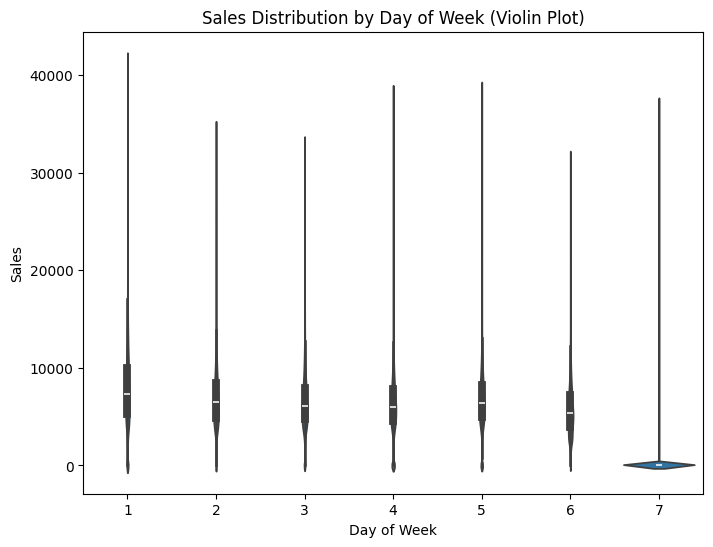

In [12]:
# Visualize outliers
plt.figure(figsize=(8, 6))
sns.violinplot(x='DayOfWeek', y='Sales', data=df, inner='box')
plt.title('Sales Distribution by Day of Week (Violin Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Sales')
plt.show()

####Observation
The initial violin plot shows sales distributions with extremely wide ranges and heavy tails across weekdays. Outliers and extreme values dominate the visualization, making it difficult to observe clear daily patterns.




In [13]:
#Remove the outliers
Q1 = train_df['Sales'].quantile(0.25)
Q3 = train_df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = train_df[(train_df['Sales'] >= lower) & (train_df['Sales'] <= upper)]

print(f"Original rows: {len(train_df)}")
print(f"Rows after cleaning: {len(df_clean)}")

Original rows: 1017209
Rows after cleaning: 990515


In [14]:
#Find the averanges of 7days
sales_by_day = df_clean.groupby('DayOfWeek')['Sales'].mean().reset_index()
print("Mean sales by DayOfWeek:")
print(sales_by_day)

Mean sales by DayOfWeek:
   DayOfWeek        Sales
0          1  7148.635847
1          2  6673.041846
2          3  6322.555999
3          4  6017.659911
4          5  6479.009788
5          6  5646.040597
6          7   132.200779


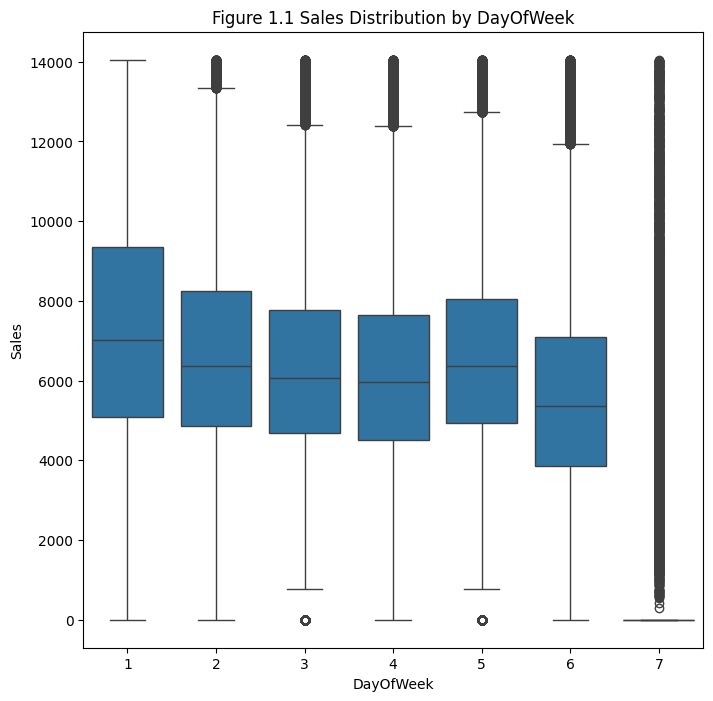

In [15]:
plt.figure(figsize=(8,8))
sns.boxplot(x='DayOfWeek', y='Sales', data=df_clean)
plt.title('Figure 1.1 Sales Distribution by DayOfWeek')
plt.xlabel('DayOfWeek')
plt.ylabel('Sales')
plt.show()

#### Purpose of the chart
Figure 1.1 presents the distribution of sales across weekdays, including the median, quartiles, and outliers. Compared with the raw violin plot before cleaning, the box plot provides a clearer and more interpretable view of sales variation.
#### Relevant to the subquestion
It addresses the subquestion about how sales differ by day of the week, with the cleaning step removing extreme noise that previously masked key patterns.
#### Key insight
Monday consistently records the highest sales, while Sunday drops sharply due to store closures. Cleaning reduces distortion from extreme outliers, making weekly seasonality much more evident.

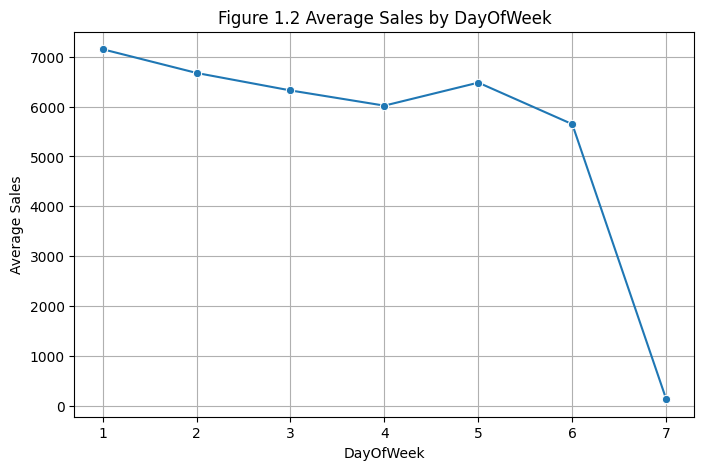

In [16]:
plt.figure(figsize=(8,5))
sns.lineplot(x='DayOfWeek', y='Sales', data=sales_by_day, marker='o')
plt.title('Figure 1.2 Average Sales by DayOfWeek')
plt.xlabel('DayOfWeek')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

#### Purpose of the chart
Figure 1.2 illustrates the trend of average sales from Monday to Sunday, providing a continuous view of changes. It complements Figure 1.1: while the box plot shows distribution, it does not clearly reveal daily average trends.
#### Relevant to the subquestion
It relates to analyzing average sales by weekday, identifying which days contribute most to revenue.
#### Key insight
Sales remain relatively stable from Tuesday to Saturday (around 6,000–6,700), peak on Monday, and collapse to nearly zero on Sunday. This reflects the operational impact of store closures.

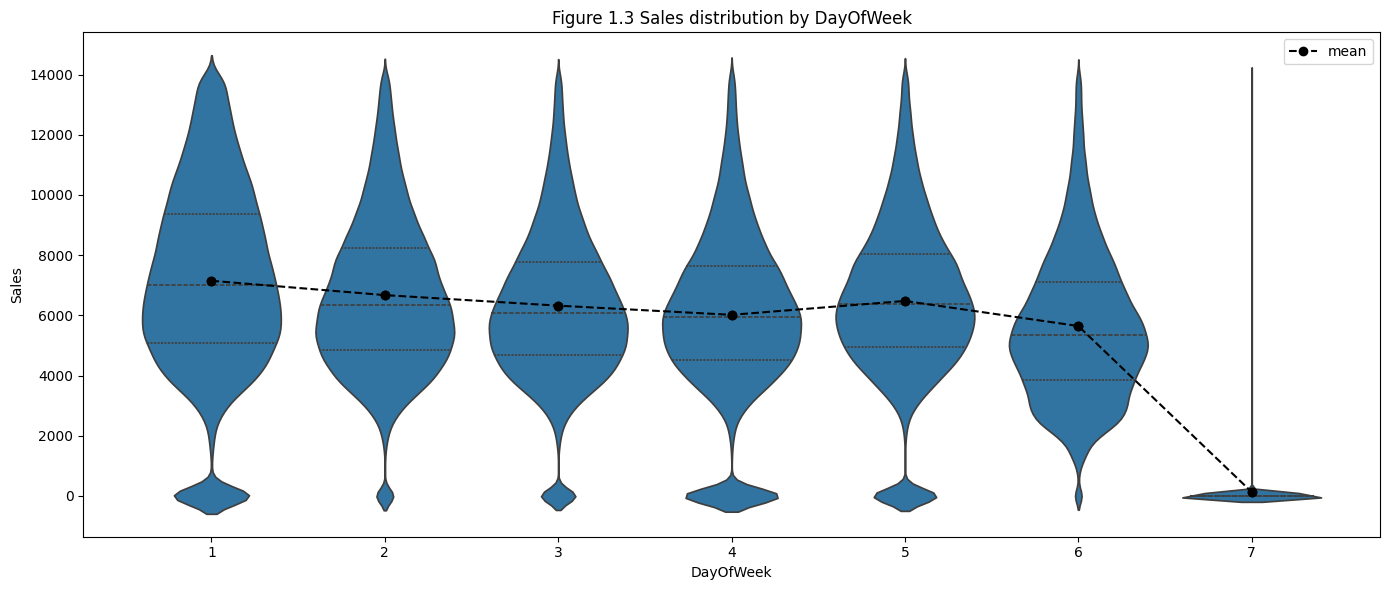

In [17]:
order = list(range(1, 8))
means = df_clean.groupby('DayOfWeek')['Sales'].mean().reindex(order)

plt.figure(figsize=(14,6))
sns.violinplot(x='DayOfWeek', y='Sales', data=df_clean, order=order, inner='quartile', scale='width')
plt.title('Figure 1.3 Sales distribution by DayOfWeek')
plt.xlabel('DayOfWeek')
plt.ylabel('Sales')

xpos = np.arange(len(order))
plt.plot(xpos, means.values, marker='o', linestyle='--', color='k', label='mean')
plt.scatter(xpos, means.values, color='k', zorder=10)
plt.legend()

plt.tight_layout()
plt.show()

#### Purpose of the chart
Figure 1.3 combines a box plot with density estimation, showing both the sales range and distribution shape. It complements Figure 1.1 by providing more detail on data concentration and skewness.
####Relevant to the subquestion
It deepens the subquestion on distribution differences across weekdays, showing how sales are spread and where they are most concentrated.
####Key insight
Monday has a wider spread with more high-value sales outliers, while Sunday is tightly concentrated at the lowest level. Mid-week days are relatively balanced around 6,000. This provides richer detail than Figure 1.1 and reinforces the weekly contrast.The violin plot successfully merges the two types of information: From the density plot: It gets the detailed shape of the distribution. From the box plot: It retains the familiar summary statistics (median, IQR) that are crucial for making quantitative comparisons.

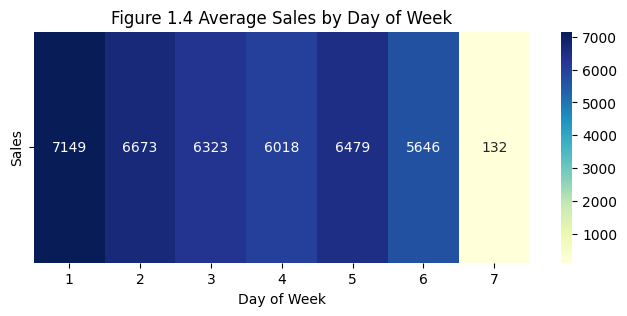

In [18]:
#Reshape for heatmap (1 row, 7 columns)
heatmap_data = sales_by_day.pivot_table(values='Sales', columns='DayOfWeek')

#Plot heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar=True)
plt.title("Figure 1.4 Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("")
plt.show()

#### Purpose of the chart
This heatmap uses color intensity to compare average sales across weekdays. It complements Figure 1.2 by providing a more intuitive visual contrast of strong vs. weak sales days.
#### Relevant to the subquestion
It contributes to the analysis of average daily sales by presenting a quick, color-coded comparison.
#### Key insight
Monday ( around 7,149) is the strongest sales day, Sunday (around 132) the weakest. Tuesday to Saturday remain stable between 6,000 - 6,600. The consistency between Figure 1.2 and Figure 1.4 strengthens the reliability of weekly seasonality findings.

## **Subquestion 2: What is the impact of promotions on sales and customer traffic?**
### Harshini - (36063592)

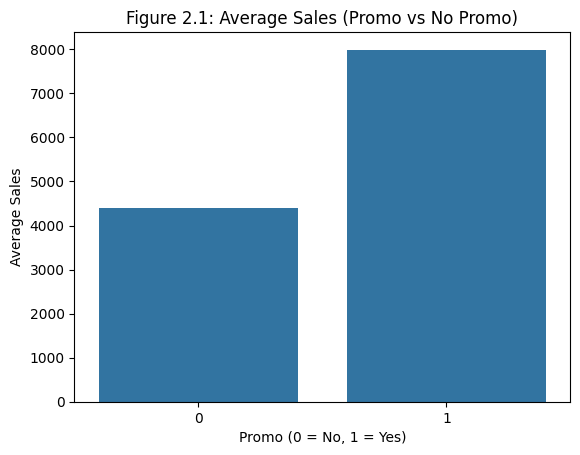

In [19]:
avg_sales = train_df.groupby("Promo")["Sales"].mean().reset_index()

sns.barplot(x="Promo", y="Sales", data=avg_sales)
plt.title("Figure 2.1: Average Sales (Promo vs No Promo)")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.show()

#### Purpose of the Chart
Figure 2.1 is a bar chart comparing the average sales between when there is no promotion and when there is a promotion. A bar chart was chosen because it makes it easy to compare these two categories as there charts are side-by-side. With this bar chart, we can also easily relationship between promotions and sales.

#### Relevance to the Subquestion
This bar chart directly addresses the aim of the subquestion which is to determine the affect of promotion on sales performance. With this bar chart, we can easily how the average sales differs in the presence or absence of promotions. By comparing the average sales in these two scenarios, we can clearly detrmine if promotions play a part in the increase of sales .

#### Key Insights
Based on the chart, it is clear that there is obvious difference in average sales between the two categories. When there is a promotion, the average sales are nearly 8,000. However, when there are no promotions, the average sales are around 4,400. This clearly shows that the average sales is nearly doubled when there is a promo indicating that promotions are strongly correlated with higher sales. This findings also aligns with what's often seen in retail, which is well-timed promotions can significantly increase sales as it could attract new customers or encourage existing customers to buy more


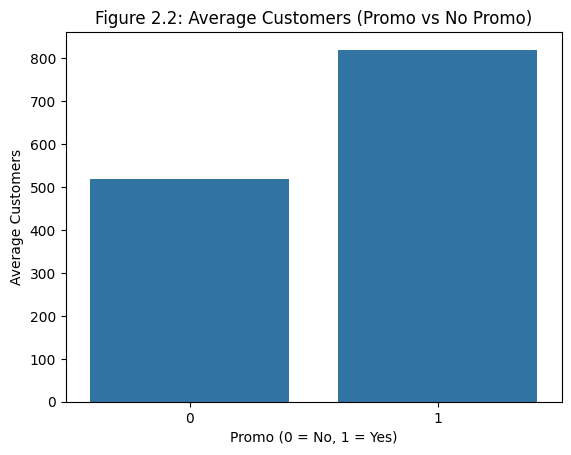

In [20]:
avg_customers = train_df.groupby("Promo")["Customers"].mean().reset_index()

sns.barplot(x="Promo", y="Customers", data=avg_customers)
plt.title("Figure 2.2: Average Customers (Promo vs No Promo)")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Customers")
plt.show()

#### Purpose of the Chart
Figure 2.2 is a bar chart displaying the average number of customer when there is no promotion and when there is promotion. A bar chart was chosen again for consistence and comparability with Figure 2.1. With this, we can easily compare the results for sales and customer numbers.

#### Relevance to the Subquestion
This bar chart also directly addresses the aim of the subquestion which questions about customer traffic. With this bar chart, we can easily see whether the promotions bring more people to the store. Customer foot traffic is important because with more customers, the sales will be higher. By comparing the average customers in these two scenarios, we can clearly detrmine if promotions play a part in the increase of customer footfall.

#### Key Insights
Figure 2.2 displays there is an average of 820 customers during promotions, compared to around 520 customers on days without promotion. There is significant difference between the two categories even though it isn't as the difference in Figure 2.1. This could suggest that promotions not only attract more people, it might also be encouraging customers to spend more. This could indicate that the promotions have a few effect, which is increase the customer traffic and raise the average transactions made.

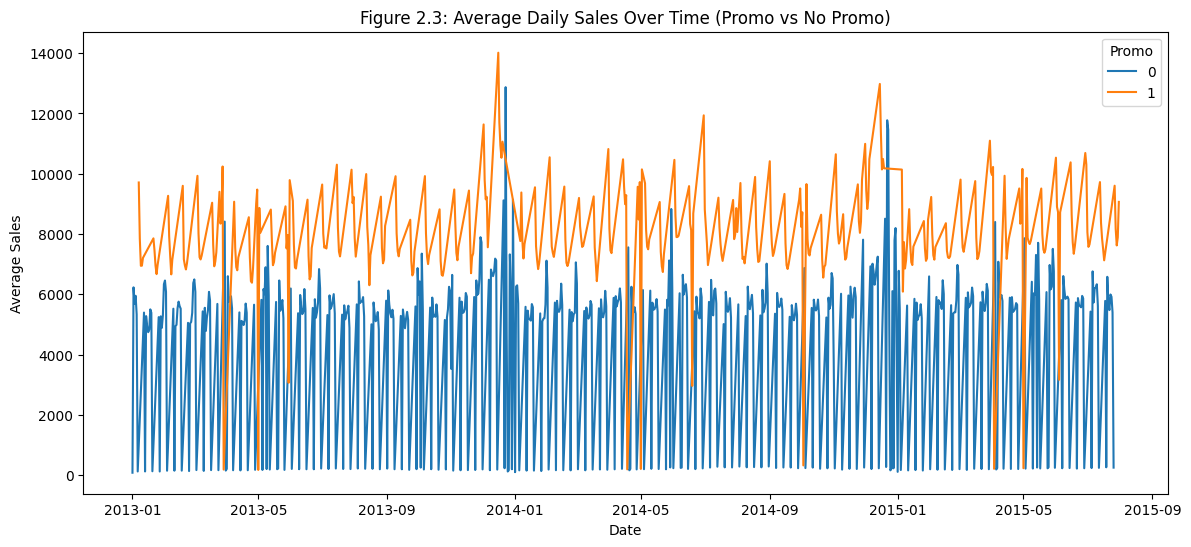

In [21]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

daily_sales = train_df.groupby(["Date", "Promo"])["Sales"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(x="Date", y="Sales", hue="Promo", data=daily_sales)
plt.title("Figure 2.3: Average Daily Sales Over Time (Promo vs No Promo)")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.legend(title = "Promo")
plt.show()

#### Purpose of the Chart
Figure 2.3 is a line graph showing the average daily sales from 2013 to 2015 when there was no promotion and there was promotion. A line chart was selected for this because it is more suitable to show how a variable, which is sales changes over time. Unlike Figure 2.1 and 2.2, which are bar charts that gives us a single average, a line charts helps us to visualize whether the difference between non-promo and promo days are consistent or if it changes. The two lines in the chart, one indicating for promo days and one for non-promo, which makes the comparison easy to follow.

#### Relevance to the Subquestion
The subquestion is about the affect of promotions, and time play an important role in understanding that affect. A time-based view helps us to determine if the sales boost from promotions happens steadily or if there are certain pattern such as seasonal spikes. It also helps us to determine whether the promotions are timed to match high demand periods, which could make them even more effective.

#### Key Insights
Figure 2.3 shows a consistent pattern. This is because the orange line which stands for sales on promotion days are always highers than blue line which stands for sales on non-promotion. This pattern remains from early 2013 to mid 2015, suggesting that the sales boost from promotion is consistent over the years. Some of the biggest spikes im promo sales happen during peak shopping times, such as the holiday season. This suggest that Rossman might have deliberately time their promotions to take advantage of periods when people are more likely to spend. It is also worth noting that both lines display regular peaks and troughs, as well as occasional large spike, that could indicate that there are other factors that are affecting the sales.

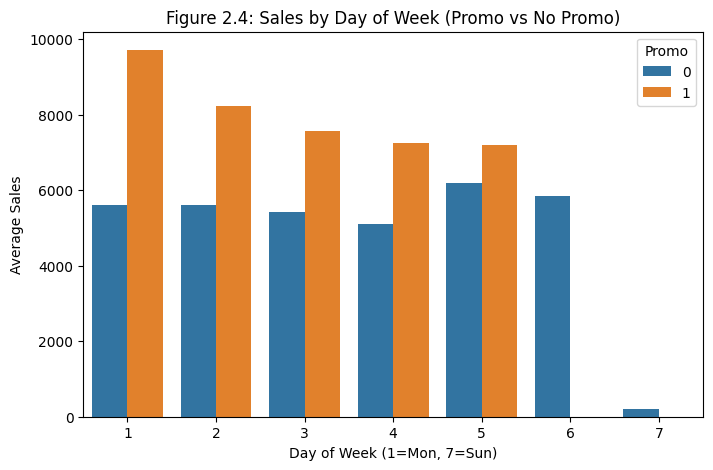

In [22]:
day_sales = train_df.groupby(["DayOfWeek", "Promo"])["Sales"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="DayOfWeek", y="Sales", hue="Promo", data=day_sales)
plt.title("Figure 2.4: Sales by Day of Week (Promo vs No Promo)")
plt.xlabel("Day of Week (1=Mon, 7=Sun)")
plt.ylabel("Average Sales")
plt.show()

### Purpose of the Chart
Figure 2.4 shows a grouped bar chart showing average sales with and without Promotion across Days of the Week. A grouped bar chart was chosen because the average sales across the days of the week is easily comparable, differentiating the sales when there is promotions and when there isn't. By separating the sales with and without promotion, the chart provides us a direct way to observe whether promotions influence sales and whether this effect is consistent across different days.

#### Relevance to the Subquestion
The subquestion focuses on the effect on promotions on sales and customer traffic. With this chart, we can observe the customer behavior by weekdays and weekends as the store traffic differs by day. This chart also makes it possible to evaluate how much influence promotions have on average sales  on different days of week.

#### Key Insights
Based on the chart, it is evident that the promotions have lead to an increase in sales across nearly all weekdays. This can be clearly seen on Mondays, suggesting that promotions that are early on the week might play a role in driving higher footfall and customer engagement. On the other hand, Sundays sales shows a sharp drop for both with and wtihout sales. This could be because most of the Rossman stores are closed on Sundays.

#### Why this finding is important
This finding is important as it can be used by Rossman store to plan their sales strategy more effectively. This is because as promotions appear most effective at the beginning of the week, managers of Rossman stires could strategically schedule promotional campaigns to boost traffic during periods where there is lesser footfall. However, it is also obvious that investing in promotions on Sunday would most likely be ineffective and wasteful as the store is closed. This shows that promotions are not equally valuable across all days, and customizing them to specific weekdays can improve cost efficience and maximize sales impact.

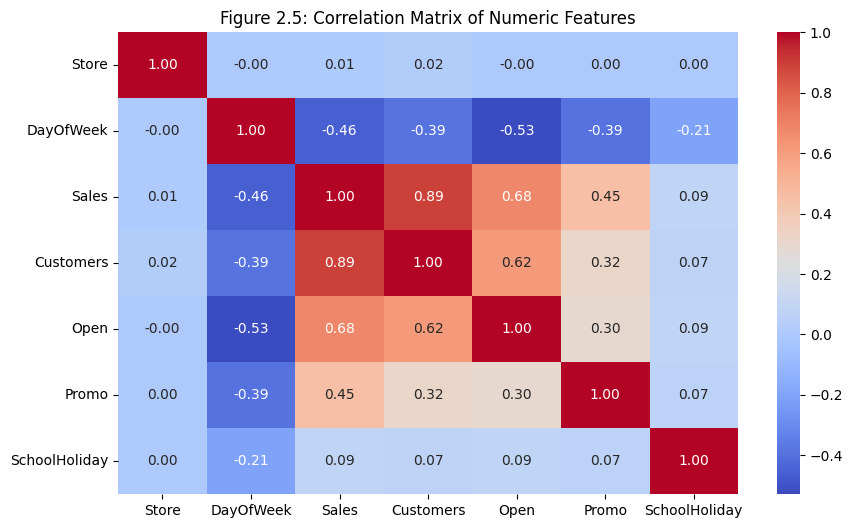

In [23]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Figure 2.5: Correlation Matrix of Numeric Features")
plt.show()

### Purpose of the Chart
Figure 2.5 shows a correlation matrix for numeric features. The correlation heatmap helps to display the linear relationships between multiple variables in the dataset and how strongly the variables influence each other. This makes it possible to evaluate whether promotions are related with higher sales and customer traffic, and how these relationships compare to other factors like day of the week or store open status.

#### Relevance to the Subquestion
The correlation heatmap directly addresses the subquestion by showing how strongly the `Promo` variable is related to `Sales` and `Customers` variable. Other than that, it also reveals the indirect ways on how the promotions might operate. For example, by having more customers, it will increase the sales numbers.

#### Key Insights
There are several key findings from the correlation heatmap.
- Firstly, the correlation between `Sales` and `Customers` is **0.89**, which is a very strong positive correlation. This confirms that the store performance is greatly influenced by the customer footfall.
- Secondly, the correlation between `Sales` and `Promo` is **0.45**, which is a moderate positive correlation. This shows that promotions are effective in boosting sales, but not as effective as customers foot traffic.
- Thirdly, the correlation between `Promo` and `Customers` is **0.32**. This means that promotions are positively associated with customer counts, showing that promotions do indeed bring more people into stores.
- Lastly, the correlation between `Sales` and `DayOfWeek` is **-0.46**, which is a negative correlation. This is because some days such as Sundays have lower sales.  

#### Why this finding is important
The correlation heatmap is important because it helps to identifies how promotions affect sales. The correlation between promotions and sales is 0.45 which is not as strong as the correlation between sales and customer count which 0.89. This suggest that promotions helps in attracting more customers to the store but doesn't help in increasing the average spend per customer.

## **Subquestion 3: What is the relationship between the number of customers and sales?**
### Christy Lee - (34475729)

### 3.1 Data Cleaning
* Clean data to include only observations with valid data

In [24]:
# Check for missing values
print("Missing values per column:")
print(train_df[['Sales', 'Customers']].isnull().sum())

# Drop rows with missing Sales or Customers
df_clean = train_df.dropna(subset=['Sales','Customers'])

Missing values per column:
Sales        0
Customers    0
dtype: int64


* Remove outliers

In [25]:
# Remove outliers from Sales and Customers
for col in ['Sales', 'Customers']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only values within bounds
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

In [26]:
print(df_clean.info())
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 967874 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          967874 non-null  int64         
 1   DayOfWeek      967874 non-null  int64         
 2   Date           967874 non-null  datetime64[ns]
 3   Sales          967874 non-null  int64         
 4   Customers      967874 non-null  int64         
 5   Open           967874 non-null  int64         
 6   Promo          967874 non-null  int64         
 7   StateHoliday   967874 non-null  object        
 8   SchoolHoliday  967874 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 73.8+ MB
None
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3     

### 3.2 Data visualisation

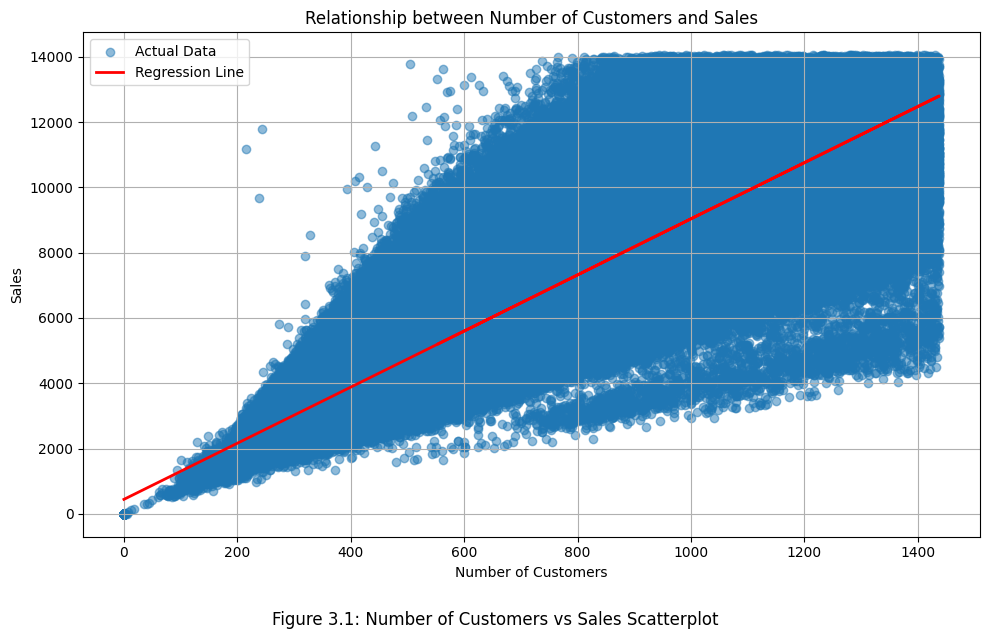

Correlation coefficient: 0.9132
p-value: 0.0
Regression slope: 8.5949
Regression intercept: 442.13
R-squared: 0.834


In [27]:
# Fit regression model
model = LinearRegression()
num_of_customers = df_clean[['Customers']]
sales = df_clean['Sales']
model.fit(num_of_customers, sales)
sales_predict = model.predict(num_of_customers)

# Calculate correlation
corr, p_value = pearsonr(df_clean['Customers'], df_clean['Sales'])

# Plot actual data
plt.figure(figsize=(10, 6))
plt.scatter(num_of_customers, sales, alpha=0.5, label='Actual Data')

# Plot regression line
plt.plot(num_of_customers, sales_predict, color='red', linewidth=2, label='Regression Line')

# Add labels
plt.legend()
plt.title('Relationship between Number of Customers and Sales')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.figtext(0.5, -0.05,
            'Figure 3.1: Number of Customers vs Sales Scatterplot',
            wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

# Print statistics
print("Correlation coefficient:", round(corr, 4))
print("p-value:", round(p_value, 4))
print("Regression slope:", round(model.coef_[0], 4))
print("Regression intercept:", round(model.intercept_, 2))
print("R-squared:", round(model.score(num_of_customers, sales), 4))

#### Purpose of the Graph
Figure 3.1 shows a scatterplot with a regression line which visualises the relationship between the number of customers and sales. A scatterplot is used as it clearly illustrates the spread of data points and identify patterns in the relationship between the two variables. Additionally, the regression line provides a clear indication of the overall trend, helping us quantify how sales are expected to change with customer numbers.

#### Relevance to the Subquestion
Figure 3.1 focuses on the subquestion by showing the strength and direction of the relationship between the `Customers` and `Sales` variables. By doing so, the graph allows us to examine how customer volume can affect sales. This would be extremely useful as customer traffic is one of the key drivers of sales in retail stores.

#### Key Observations
**Correlation**

The correlation coefficient obtained from Figure 3.1 is **0.9139**. This indiciates a **very strong positive relationship** between number of customers and sales.

**Regression line**

The regression slope obtained from Figure 3.1 is **8.5912**. This shows that **for every 1 customer increase**, there is an increase of about **8.59** units in sales.

**R-squared value**

The R-squared value obtained from Figure 3.1 is **0.8352**. This explains that about **83.52%** of variation in sales is associated with the number of customers.

### 3.3 Data Analysis
The results reveal a **very strong positive relationship** between the number of customers and sales, with a correlation coefficient of **0.9139**. This indicates that as the number of customers increases, sales also tend to increase in a consistent manner. The regression line further supports this finding, with a slope of **8.5912**, suggesting that for **every 1 customer increase**, **sales** are expected to **increase** by approximately **8.59 units**. Besides, the **R-squared value** of **0.8352** shows that about **83.52%** of variation in sales can be explained by the number of customers.

These results clearly show that customer traffic plays an important role in affecting sales, making customer traffic a reliable factor on predicting sales. This implies that higher customer traffic will always translate to higher sales revenue. From a business perspective, relevant stakeholders should make customer retention a priority in order to maximise sales growth.

## **Subquestion 5: ⁠Are there seasonal or monthly trends in sales performance?**
### Heidi Swee Lin Tan - (36391158)

### 5.1 Cleaning the data:

In [28]:
# Drop rows with missing Dates or Sales
df_clean = train_df.dropna(subset=['Date','Sales'])

### Removing the outliers:

In [29]:
#Remove outliers in Sales:
Q1 = df_clean['Sales'].quantile(0.25)
Q3 = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Only keep values within the bounds
df_clean = df_clean[(df_clean['Sales'] >= lower_bound) & (df_clean['Sales'] <= upper_bound)]

In [30]:
print(df_clean.info())
print(df_clean.head())
print(df_clean.tail())

<class 'pandas.core.frame.DataFrame'>
Index: 990515 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          990515 non-null  int64         
 1   DayOfWeek      990515 non-null  int64         
 2   Date           990515 non-null  datetime64[ns]
 3   Sales          990515 non-null  int64         
 4   Customers      990515 non-null  int64         
 5   Open           990515 non-null  int64         
 6   Promo          990515 non-null  int64         
 7   StateHoliday   990515 non-null  object        
 8   SchoolHoliday  990515 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 75.6+ MB
None
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3     

### Aggregating the sum of sales per month:
The original dataset included both the year and month together in the same columns. After separating the year and the months into separate columns, the following table displays the monthly sales performance from January 2013 to July 2015,

In [31]:
# Convert the 'Date' column to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Extract year and month into new columns
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

# Simple monthly aggregation (sum of sales per month)
monthly_sales = df_clean.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
# Display the DataFrame with comma-formatted sales
display(monthly_sales.style.format({'Sales': '{:,}'}))

,Year,Month,Sales
0,2013,1,"170,666,497"
1,2013,2,"161,186,274"
2,2013,3,"183,520,360"
3,2013,4,"172,070,966"
4,2013,5,"172,044,775"
5,2013,6,"171,188,546"
6,2013,7,"192,556,862"
7,2013,8,"185,903,824"
8,2013,9,"168,244,618"
9,2013,10,"177,266,554"


### 5.2 Data visualisation:

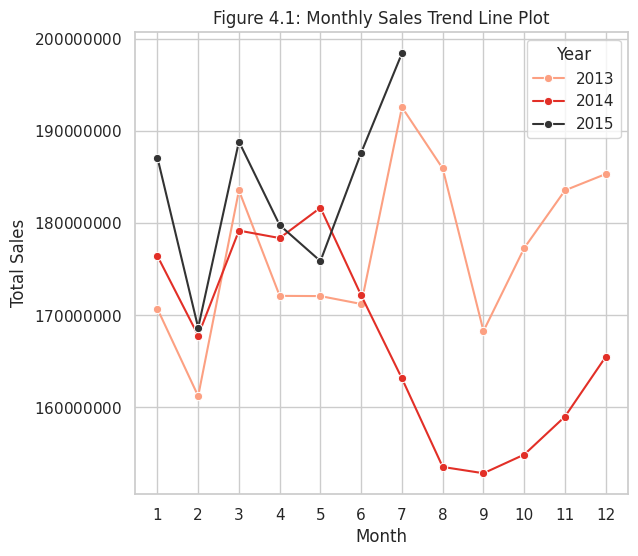

In [38]:
# Set style for better visuals
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Monthly Sales Trend Line Plot
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_sales,
             x='Month',
             y='Sales',
             hue='Year',
             palette='Reds_d',
             marker='o')
#Add labels to axes
plt.title('Figure 4.1: Monthly Sales Trend Line Plot')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))  # Ensure all months are shown
plt.ticklabel_format(axis='y', style='plain', useMathText=True) #To format y-axis to display whole numbers instead of scientific notation (e.g: 1e6)

### Key Observations:

1. **Y-Axis (Total Sales)**:

Ranges from approximately 160,000,000 to 200,000,000. Sales figures are in the hundreds of millions.

2. **X-Axis (Month):**

Represents months 1 (January) to 12 (December).

3. **Trend Lines:**

Three lines (one for each year: 2013, 2014, 2015) show fluctuations in monthly sales.
There seems to be seasonality, with sales peaking at certain months (possibly mid-year or towards the end) and dipping in others.
2015 appears to have the highest sales compared to the previous two years.

4. **General Pattern:**

Sales increase significantly in some months, suggesting possible seasonal demand (e.g., holidays, promotions).
The overall trend may be upward, as 2015's sales are mostly higher than 2013 and 2014.

5. **Possible Interpretations:**

The business experiences strong seasonal peaks, possibly tied to events or shopping seasons.
Year-over-year growth is evident, with 2015 outperforming prior years.
The lowest sales seem to occur in early months (January-March) or towards the end of the year (November-December). In 2 out of 3 three years (2013 and 2015), February was recorded to have the lowest profits. In 2014, September showed the lowest ever profit sales in that year, and as well as 2013 and 2015 combined.

### Creating 3 separate visualisations for each year (2013, 2014 & 2015):
* This is just to clearly see and compare the monthly trends within each year. The line plots are essentially used to see the movement and the overall direction of the trend, without the exact numerical information. Detailed explanations are included below the bar plots to further elaborate with the exact numbers.

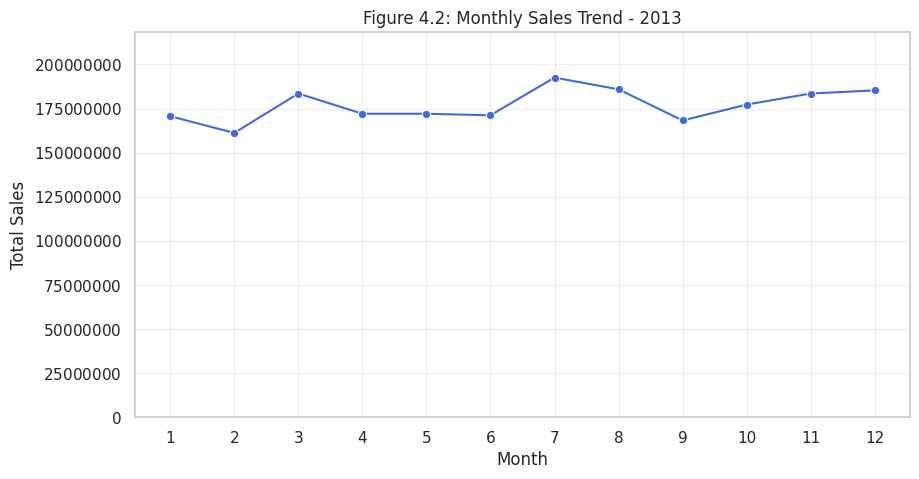

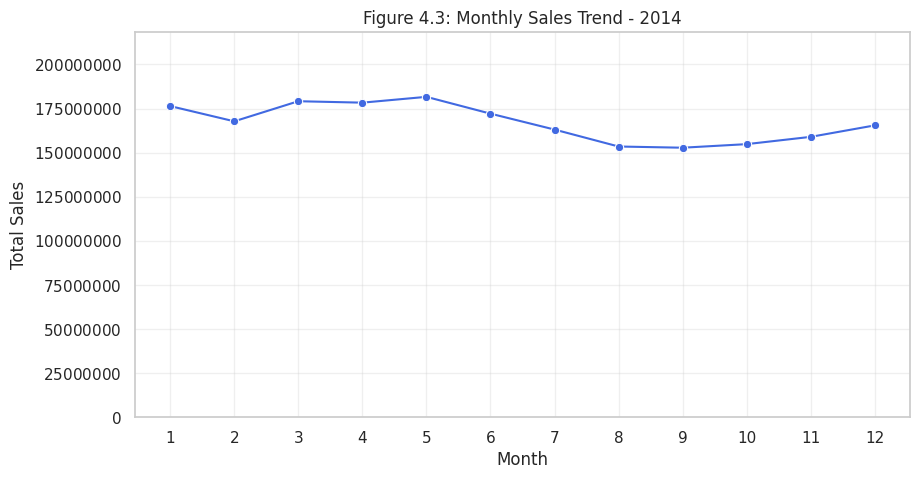

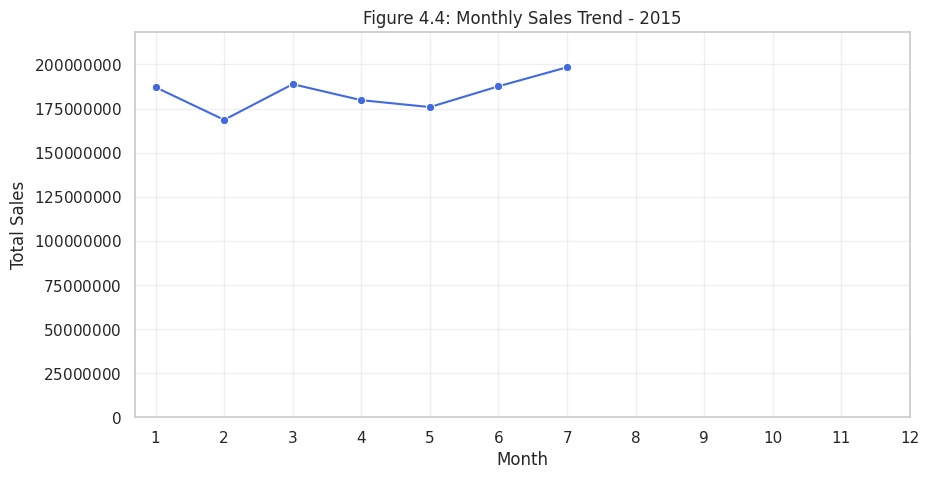

In [39]:
# Get unique years from the data
years = monthly_sales['Year'].unique()

# Set style for all plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Create separate line plots for each year with figure numbers
for i, year in enumerate(years, start=2):  # Start from 2 for fig4.2, fig4.3, etc.
    year_data = monthly_sales[monthly_sales['Year'] == year]

    plt.figure()
    sns.lineplot(data=year_data,
                 x='Month',
                 y='Sales',
                 marker='o',
                 color='royalblue')

    # Add labels to axes with figure number
    plt.title(f'Figure 4.{i}: Monthly Sales Trend - {year}')
    plt.xlabel('Month')
    plt.ylabel('Total Sales')
    plt.xticks(range(1, 13))  # Ensure all months are shown
    plt.ylim(0, monthly_sales['Sales'].max() * 1.1)  # Consistent y-axis scale
    plt.grid(True, alpha=0.3)
    plt.ticklabel_format(axis='y', style='plain', useMathText=True)
    plt.show()

### Creating bar plots to compare exact monthly sales values, instead of movement or direction:
A bar plot is generally much easier to see the precise increase and decrease of monthly sales performance, which is why this type of plot has been chosen to decribe the monthly profits.

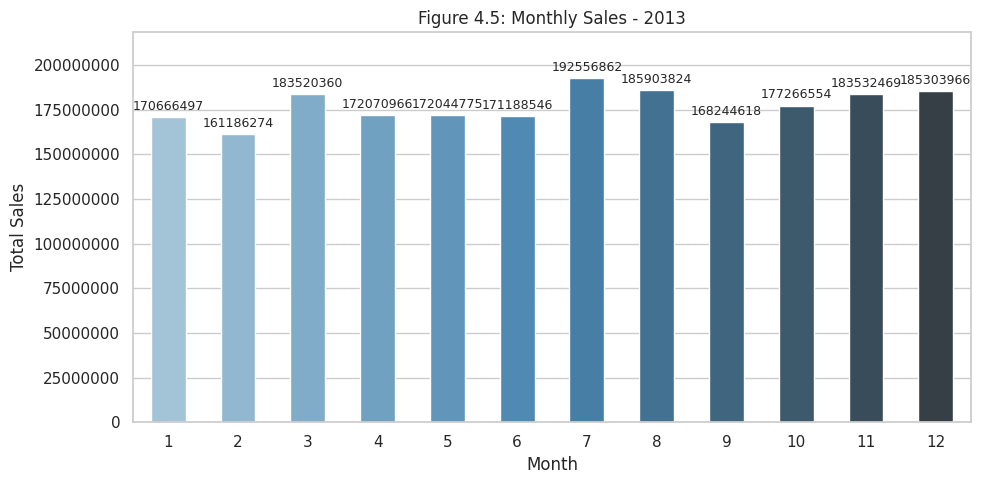

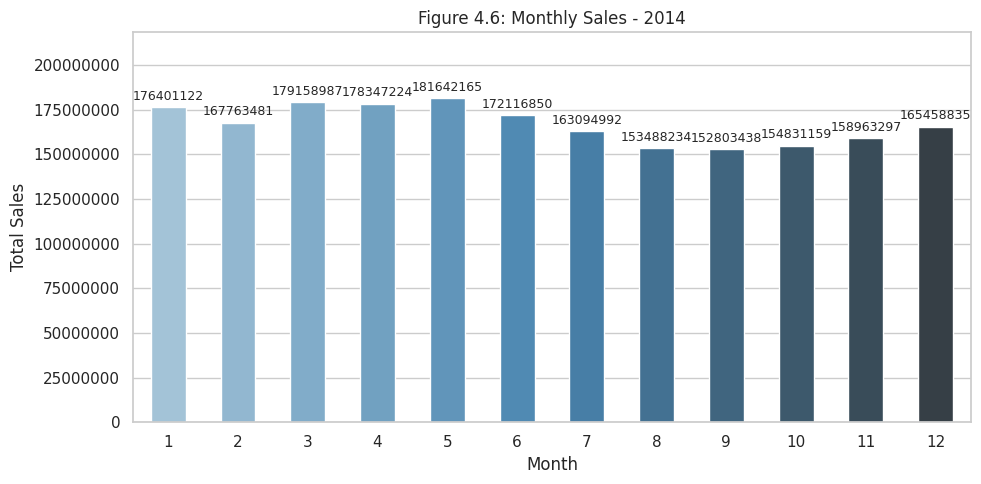

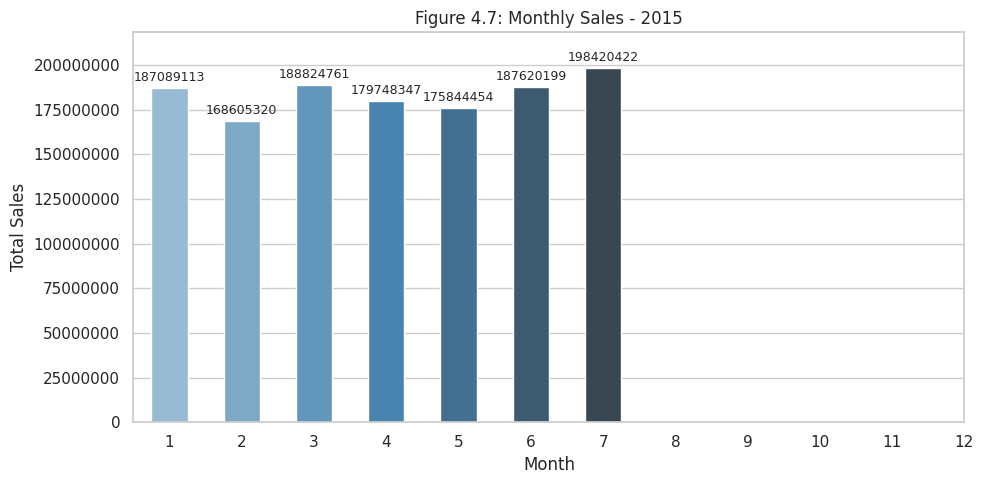

In [40]:
# Create separate bar plots for each year
for i, year in enumerate(years, start=5):  # Start from 5 for fig4.5, fig4.6, etc.
    year_data = monthly_sales[monthly_sales['Year'] == year]

    # Making the bar plot
    plt.figure()
    ax = sns.barplot(data=year_data,
                    x='Month',
                    y='Sales',
                    palette='Blues_d',
                    width=0.5)

    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container,
                    fmt='%.0f',  # Format as whole numbers
                    label_type='edge',
                    padding=3,  # Space between bar and label
                    fontsize=9)

    # Add labels to axes with figure number
    plt.title(f'Figure 4.{i}: Monthly Sales - {year}')
    plt.xlabel('Month')
    plt.ylabel('Total Sales')
    plt.xticks(ticks=range(12), labels=range(1, 13))  # Show all months
    plt.ticklabel_format(axis='y', style='plain')  # To format y-axis to display whole numbers instead of scientific notation (e.g: 1e6)
    plt.ylim(0, max(monthly_sales['Sales']) * 1.1)  # Add space for labels
    plt.tight_layout() #Adjust spacing to prevent label collisions
    plt.show()

### 5.3 Observations


1. **Monthly Sales - 2013**

The lowest sales performance in 2013 was in February with a value of 161,186,274, meanwhile the most money earned that year was in July with a value of 192,556,864. The months April, May and June have relatively similar values of around 172,000,000. The profits throughout the year fluctuate between roughly 160,000,000 and 200,000,000.

2. **Monthly Sales - 2014**

In 2014, from January to May, the profits earned remained relatively similar at around 180,000,000 , except for February, where the value was slightly lower around 170,000,000. May was recorded to have the highest sales performance of around 182,000,000. After May, the values decrease until September, where the lowest sales thar year performance was around 153,000,000. After September, the monthly sales begin to increase again until December, where the final sales performance value was around 165,000,000.

3. **Monthly Sales - 2015**

The dataset only included the profits from January to July, with values of approximately 187,000,000 and 198,000,000 respectively. Between those seven months, the values increase and decrease almost every two months. For example, from March to May, the profits decreased from 189,000,000 to 176,000,000. The following two months, the profits then increased to 198,000,000 in July, which is also the highest profit value earned among those seven months. February was also recorded to have the lowest monthly sales among the rest, with a value of 169,000,000.  

### Rolling Means (Daily, 7, and 30-day):
Given the high variability in daily sales data, rolling averages provide a clearer view of underlying business trends. The 7-day and 30-day rolling means filter out noise from daily operations to highlight sustained changes in sales performance over time.

Rolling means work better with daily data because you have many more data points (over 1,000 daily observations versus only 36 monthly ones), which provides more reliable trend smoothing. Monthly data is already aggregated and smoothed, so adding rolling means on top might over-smooth important patterns and make seasonal trends harder to detect.

In [46]:
# See what columns there are
daily_sales_df = daily_sales.reset_index()
print("Current columns:", daily_sales_df.columns.tolist())
print("Shape:", daily_sales_df.shape)
display(daily_sales_df.head())

Current columns: ['index', 'Date', 'Promo', 'Sales']
Shape: (942, 4)


,index,Date,Promo,Sales
0,0,2013-01-01,0,87.284560
1,1,2013-01-02,0,6233.030493
2,2,2013-01-03,0,5693.112108
3,3,2013-01-04,0,5954.218834
4,4,2013-01-05,0,5337.751570


In [45]:
# Create a formatted display
daily_sales_df = daily_sales.reset_index()

# Drop the unnecessary 'index' column and rename 'Sales' to 'Daily_Sales'
daily_sales_df = daily_sales_df.drop(columns=['index'])
daily_sales_df = daily_sales_df.rename(columns={'Sales': 'Daily_Sales'})

# Format the sales column as currency
daily_sales_df['Daily_Sales_Formatted'] = daily_sales_df['Daily_Sales'].apply(lambda x: f'${x:,.2f}')

# Display selected columns
display(daily_sales_df[['Date', 'Daily_Sales_Formatted']].head(20))
display(daily_sales_df[['Date', 'Daily_Sales_Formatted']].tail(20))

,Date,Daily_Sales_Formatted
0,2013-01-01,$87.28
1,2013-01-02,"$6,233.03"
2,2013-01-03,"$5,693.11"
3,2013-01-04,"$5,954.22"
4,2013-01-05,"$5,337.75"
5,2013-01-06,$129.06
6,2013-01-07,"$9,710.18"
7,2013-01-08,"$7,847.03"
8,2013-01-09,"$6,947.63"
9,2013-01-10,"$6,952.00"


,Date,Daily_Sales_Formatted
922,2015-07-12,$248.47
923,2015-07-13,"$9,723.11"
924,2015-07-14,"$8,377.04"
925,2015-07-15,"$7,853.04"
926,2015-07-16,"$7,510.20"
927,2015-07-17,"$7,129.45"
928,2015-07-18,"$5,783.84"
929,2015-07-19,$267.64
930,2015-07-20,"$6,582.35"
931,2015-07-21,"$5,700.88"


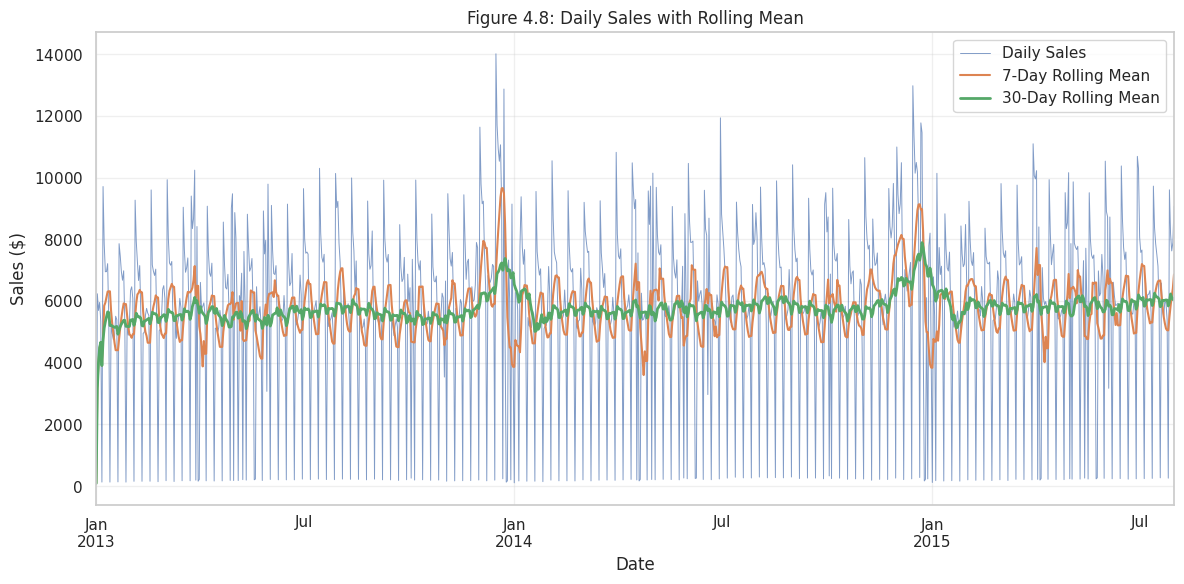

In [51]:
daily_sales_series = daily_sales_df.set_index('Date')['Sales']

# Compute rolling means
rolling_7d = daily_sales_series.rolling('7D').mean()  # 7-day rolling average
rolling_30d = daily_sales_series.rolling('30D').mean()  # 30-day rolling average

# Plot
plt.figure(figsize=(12, 6))
daily_sales_series.plot.line(label='Daily Sales', linewidth=0.7, alpha=0.7)
rolling_7d.plot.line(label='7-Day Rolling Mean', linewidth=1.5)
rolling_30d.plot.line(label='30-Day Rolling Mean', linewidth=2)

# Add title and labels
plt.title('Figure 4.8: Daily Sales with Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.ticklabel_format(axis='y', style='plain', useMathText=True)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Purpose of the Chart
This figure is a time series line chart displaying daily sales data from 2013 to 2015, enhanced with 7-day and 30-day rolling averages. A line chart was selected because it effectively demonstrates how sales performance evolves over time, revealing both short-term fluctuations and long-term trends. The inclusion of rolling averages is particularly valuable as it smooths out daily volatility to expose underlying patterns that would be obscured by the raw daily data alone. The three-line approach allows for multi-level analysis: daily granularity for detailed examination, weekly smoothing for short-term trends, and monthly smoothing for strategic insights.

### Relevance to Business Performance Analysis
This temporal visualization is crucial for understanding overall business health and identifying performance cycles. Time-based analysis helps determine whether sales patterns are predictable, seasonal, or influenced by external factors. The rolling averages particularly help distinguish between normal business fluctuations and genuine trend changes, which is essential for strategic decision-making and resource allocation.

### Key Insights
1. **Consistent Baseline Performance** : The 30-day rolling average reveals that the business maintains a relatively stable foundation, typically operating between $5.5-6.5M in daily sales. This consistency suggests a reliable customer base and stable market position.

2. **Cyclical Volatility Patterns** : The daily sales line shows regular peaks and troughs throughout the entire period, indicating predictable demand cycles. These could correspond to weekly patterns (weekend vs. weekday shopping), payroll cycles, or other recurring customer behavior patterns.

3. **Notable Performance Decline** : A significant trend emerges in mid-2014 through early 2015, where the 30-day rolling average drops noticeably below the historical baseline. This sustained decline suggests systematic factors rather than random fluctuation - potentially market conditions, competitive pressure, or operational changes during this period.

4. **Strong Recovery Trajectory** : Following the 2014-2015 dip, there's a clear recovery pattern visible in the rolling averages, with performance returning to and occasionally exceeding historical levels by late 2015. This resilience indicates effective business adaptation and recovery strategies.

5. **Amplitude Consistency** : Despite the temporary decline, the daily volatility range remains relatively consistent throughout the period, suggesting that while overall volume may have shifted, the fundamental demand patterns and customer behavior remained stable.











## **PART 3: Data Modelling**

Based on the Exploratory Data Analysis, it is clear that `Customers` influence `Sales` the most, while `Promo` and `DayOfWeek` also play meaningful roles.

- `Customer`: Based on the analysis done, the `Customers` variable showed a very strong positive correlation with `Sales`. The correlation coeeficient was around 0.89 and the regression analysis gave an R2 value of around 0.83. This indicates that customer traffic alone explains more then 80% of the variation in sales.

- `Promo`: From the analysis. the `Promo` variable showed a positive impact on `Sales`. Average sales are noticeably higher during promotional periods compared to non-promotional days. This suggest that promotions are effective in increasing both customer traffic and sales.

- `DayOfWeek`: The analysis revealed that `DayOfWeek` influences sales patterns. This is because sales tend to be lower on certain days such as Sunday and higher on weekdays. This highlights how weekly shopping patterns affect sales.

To evaluate how well these variables canpredict sales, we now use regression models. We'll start by by using Linear, Polynomial and KNN Regression.


### Linear Regression


Linear Regression RMSE: 1726.5056494873818
Linear Regression R2: 0.7984405408620802


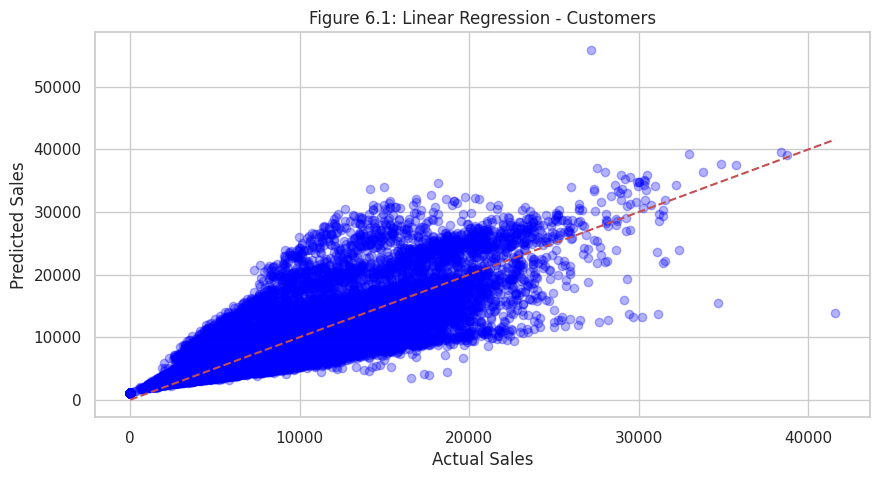

In [52]:
# Features & target
X_one = train_df[["Customers"]]
y_one = train_df["Sales"]

X_one_train, X_one_test, y_one_train, y_one_test = train_test_split(X_one, y_one, test_size=0.2, random_state=42)

#Linear Regression (Customer variable)
model_one = LinearRegression()
model_one.fit(X_one_train, y_one_train)
y_pred_one = model_one.predict(X_one_test)

rmse_one = np.sqrt(mean_squared_error(y_one_test, y_pred_one))
r2_one = r2_score(y_one_test, y_pred_one)
print("Linear Regression RMSE:", rmse_one)
print("Linear Regression R2:", r2_one)

#Plot
plt.scatter(y_one_test, y_pred_one, color='blue', alpha=0.3)
plt.plot([y_one_test.min(), y_one_test.max()], [y_one_test.min(), y_one_test.max()], 'r--')
#plt.plot(X_one_test, y_pred_one, color = "red")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Figure 6.1: Linear Regression - Customers")
plt.show()

#### Purpose of the Chart
Figure 6.1 shows the relationship between actual sales and predicted sales when using linear regression model with only the `Customers` variable as the predictor. The diagonal red line represents the line of perfection where the predicted sales is the same as the actual sales. The scatter points indicate how close the model's prediction are to actual sales values.

#### Relevance to Research Question
Figure 6.1 is relevant to the research question because The chart demonstrates how strongly customer traffic alone influence and predict sales. It helps to us visually evaluate whether the number of customers is reliable and sufficient for sales performance.

#### Key findings
The R2 value of 0.798 indicates that about 79.8% of the variation in sales can be explained by the number of customers alone.The RMSE value of around 1726 shows the average prediction error, which means that the predicted sales are off by about 1726 units on average. The scatter points follow a clear upward trend along the red line, confirming a string linear relationship between customers and sales. However, at higher sales levels, the kodel starts to deviate from the red line, suggesting some underestimation of very high sales.

#### Why this finding is important
The results confirms that customers are the strongest driver of sales performance. The high R2 value shows that the number of customers is a strong and reliable way to predict sales. For store managers this means that bringing in more customers and keeping them coming back is one of the most important ways to increase sales. However, the underestimation at extreme values highlights that there are some other additional factors that influence the sales.

Linear Regression RMSE: 1558.0169351908867
Linear Regression R2: 0.8358610976766538


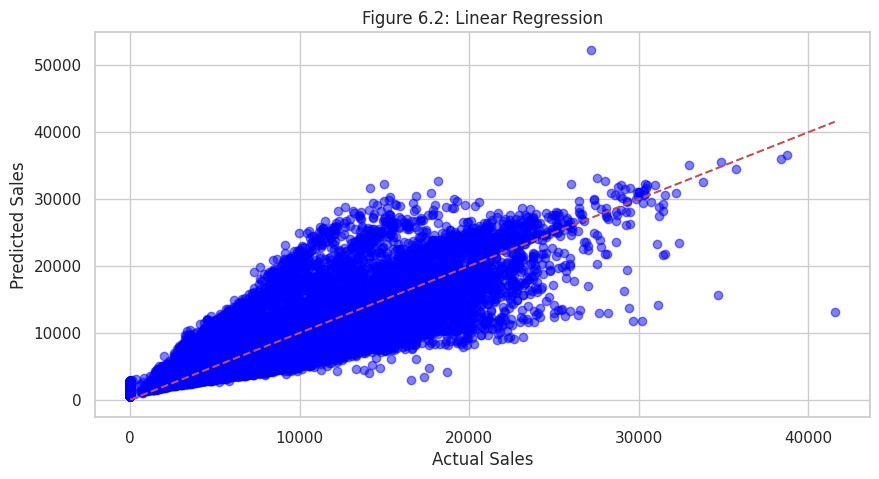

In [53]:
# Select relevant variables
X = train_df[['Customers', 'Promo', 'DayOfWeek']]
y = train_df['Sales']

#Train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

#Predict
y_pred = model.predict(X_test)

#Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

#Plot
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Figure 6.2: Linear Regression")
plt.show()

#### Purpose of the Chart
The purpose of Figure 6.2 is to model the relationship between the predictor variables `Customers`, `Promo`, `DayOfWeek` and the prediction variable `Sales` under the assumption that it is a linear relationship. This provides an simple way to interpret and understand how sales respond to these features

#### Relevance to Research Question
Figure 6.2 is relevant to the research question because the question is about understand and predicting sales pattern. It helps to understand what drives the sales.It's useful to see if the sales influenced by the straightforward factors such as customers. promotions and day of week.

#### Key findings
Firstly, the error metrics shows RMSE of 1558 and R2 is 0.836. For RMSE, it means that on average, the predictions are about 1,558 sales units away from actual sales. For R2, it means that about 83.6% of the variation in sales is explained by the model, which is fairly strong.
The scatterplot shows that most predicted values follow the upward trend of actual sales. However, the model tends to underestimate high sales values such as above 20,000. This suggests the linear assumption struggles with extreme sales peaks. For low and mid-range sales, the predictions are fairly consistent.
The model implies that sales are largely driven by straight-line effects. However, the underestimation at the higher end suggests that some factors may interact in ways that a linear model cannot capture.

#### Why this finding is important
Linear regression shows that Rossmann’s sales are indeed influenced by clear and measurable drivers like promotions. This makes it useful for managers who to have a simple interpretable model for decision-making. It confirms that fundamental drivers explain the majority of sales performance which are around 83.6%. However, the errors at extreme sales levels warn that linear models may oversimplify reality.

### Polynomial Regression

Polynomial Regression RMSE: 1413.0889041490045
Polynomial Regression R2: 0.8649774986539249


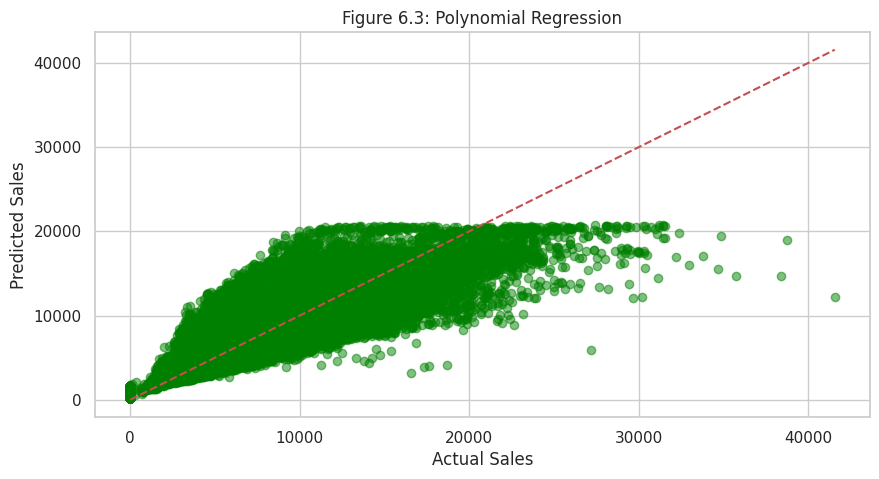

In [54]:
# Create polynomial regression
poly = PolynomialFeatures(degree=2)

# Transform the training and test sets
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Fit Linear Regression on the transformed features
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_poly, y_train)

#Predict
y_poly_pred = lin_reg_poly.predict(X_test_poly)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_poly_pred))
r2_poly = r2_score(y_test, y_poly_pred)


#Evaluate
print("Polynomial Regression RMSE:", rmse_poly)
print("Polynomial Regression R2:", r2_poly)


#Plot
plt.scatter(y_test, y_poly_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Figure 6.3: Polynomial Regression")
plt.show()

#### Purpose of the Chart
Figure 6.3 which is a polynomial regression chart helps to evaluate if allowing non-linear patterns improves the prediction of Rossmann’s sales. By including polynomial terms, the model can capture curved and interactive effects between predictors, making it better suited for complex retail environments where sales predicting variable do not act in a straight line.

#### Relevance to the Research Question
As the research question focuses on what are the factors that influence the sales, this chart is highly relevant because it shows whether Rossmann’s sales drivers are complex rather than simple and direct.
As the polynomial regression model fits the data better than linear regression, it shows that Rossmann’s sales are not explained by simple one-to-one relationships. Instead, different factors combine and influence each other. For example, the impact of promotions may change depending on the which day of the week.

### Key Findings
The error metrics shows the RMSE value is around 1413, which is lower than the linear model which had RMSE of around 1558. This means that the predictions of polynomial regressions are more accurate. The polynomial regression also have R2 value of 0.865, which is slightly higher than linear model's R2 value of 0.836, proving that the models explains more variance in sales.
The polynomial regression also performs better for mid-range sales, which are around 5,000 to 20,000. However, it still struggles with very high sales and doesn't fully capture the biggest sales spikes.
The improved performance confirms that sales predictors variables are not completely linear.

#### Why this finding is important
These findings are important because the polynomial regression model highlights that Rossmann’s sales success is influenced by non-linear factors. If Rossmann relied only on linear assumptions, they might oversimplify decisions such as assuming that increasing promotions always brings proportionally higher sales.
By recognizing non-linear dynamics, Rossmann can design smarter strategies such as promotion. As an example, Rossman can have more promotions instead of over-investing in campaigns that are barely helping in boosting sales
In conclusion, the polynomial regression chart provides evidence that sales drivers are not one-dimensional. This pushes the analysis towards identifying which non-linear patterns such as promotion contribute most to Rossmann’s overall sales success.

### KNN Regression

KNN RMSE: 1579.7301881513786
KNN R2: 0.8312541846985321


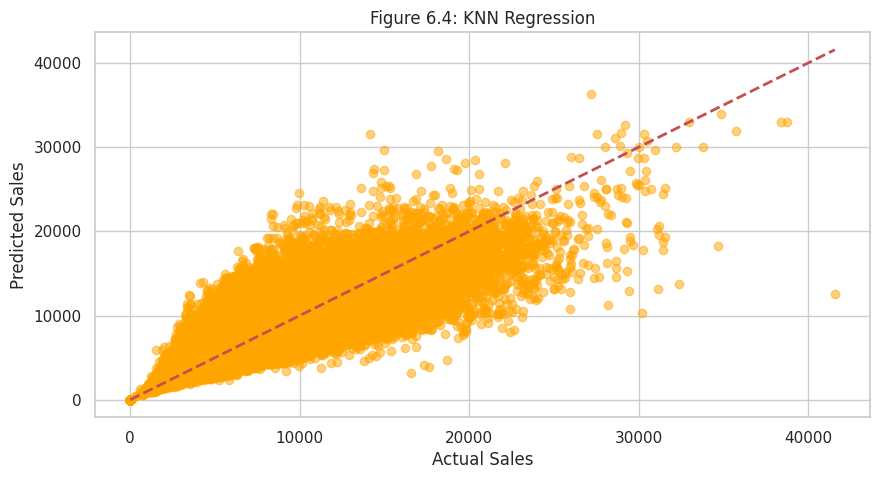

In [55]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

# Predictions
y_knn_pred = knn.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_knn_pred))
r2_knn = r2_score(y_test, y_knn_pred)

# Evaluation
print("KNN RMSE:", rmse_knn)
print("KNN R2:", r2_knn)

#Plot
plt.scatter(y_test, y_knn_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Figure 6.4: KNN Regression")
plt.show()

#### Purpose of the Chart
Figure 6.4 shows the relationship between actual sales values and the sales predicted. The orange scatter points represent individual predictions compared to its actual values. The red dashed line is the ideal line where predicted is the same as actual. The KNN regression visualization is used to check how well the KNN model’s predictions align with the real-world sales values.

#### Relevance to Research Question
Figure 6.4 shows how well the KNN model can capture and predict Rossmann’s sales performance based on the identified influencing factors such as customers, promotions and day of the week. By showing the difference between actual sales and predicted sales, the chart links the factors used in the model to the goal of finding out what drives sales success. It highlights how data analysis can help identify and measure the main things that affect sales performance.

#### Key Findings
The scatter points generally follows the red line, indicating that the KNN model captures the overall trend in the date well. The performance metrics RMSE and R2 confirms the accuracy of the model. This is because RMSE is around 1579. This means that on average, the model’s predictions are about 1579 sales units away from the actual values. The R2 is around 0.83. This means that about 83% of the variation in actual sales is explained by the model. This means that it is a good fit.

However, the KNN model also have a wider spread at higher values. Predictions for larger sales values such as sales above 20,000 show more scatter and error compared to lower sales. This suggests KNN struggles slightly with extreme or high sales numbers.

#### Why this finding is important
Firstly, it is important for model reliability. The R2 value of 0.83 indicates that the KNN model is performing well and can be trusted for predicting sales within a reasonable error margin.
Other than that, with the RMSE around 1579, this aloows the stakeholders know how much error to expect when using this model to forecast future sales. This is important for planning, inventory, or revenue management.
On the other hand, the higher spread at extreme sales values shows that the model may underperform in rare or high-demand cases. Recognizing this limitation helps decide whether KNN is the best choice, or if other models might handle extremes better.

### Logistic Regression
Christy Lee (34475729)

#### Binary Logistic Regression

In [56]:
# Create binary target: High sales if above median, else low
df_clean['HighSales'] = (df_clean['Sales'] > df_clean['Sales'].median()).astype(int)

# Define features (Customers, Promo, DayOfWeek) and target (HighSales)
X_binary = df_clean[['Customers', 'Promo', 'DayOfWeek']]
y_binary = df_clean['HighSales']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Logistic Regression model
binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = binary_model.predict(X_test)
print(f"Binary Classification Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification report:")
print(classification_report(y_test, y_pred))

Binary Classification Accuracy: 0.86

Confusion matrix:
[[127845  20776]
 [ 20060 128474]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86    148621
           1       0.86      0.86      0.86    148534

    accuracy                           0.86    297155
   macro avg       0.86      0.86      0.86    297155
weighted avg       0.86      0.86      0.86    297155



#### Explanation
- Model correctly classified **86%** of the test samples
- Confusion matrix:
  - **True Negatives (TN): 124,503** → Model correctly predicted Low Sales.
  - **False Positives (FP): 20,719** → Model incorrectly predicted High Sales when sales were actually low.
  - **False Negatives (FN): 19,336** → Model incorrectly predicted Low Sales when sales were actually high.
  - **True Positives (TP): 125,805** → Model correctly predicted High Sales.

#### Visualisation - ROC (Receiver Operating Characteristic) Curve

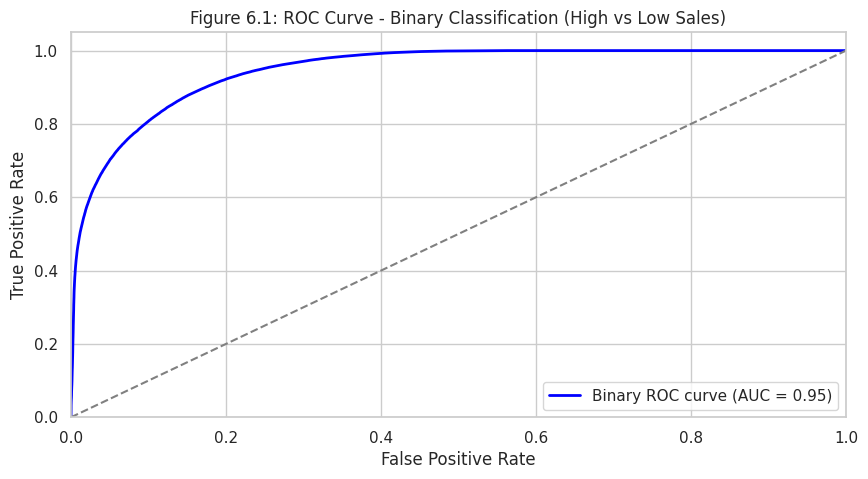

In [57]:
# Create binary target: High sales if above median, else low
df_clean['HighSales'] = (df_clean['Sales'] > df_clean['Sales'].median()).astype(int)

# Define features and target
X_binary = df_clean[['Customers', 'Promo', 'DayOfWeek']]
y_binary = df_clean['HighSales']

# Split into training and testing sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Standardize the features
scaler = StandardScaler()
X_train_bin = scaler.fit_transform(X_train_bin)
X_test_bin = scaler.transform(X_test_bin)

# Train Logistic Regression for binary classification
clf_bin = LogisticRegression(max_iter=1000)
clf_bin.fit(X_train_bin, y_train_bin)

# Predict probabilities for the binary classifier
y_scores_bin = clf_bin.predict_proba(X_test_bin)[:, 1]

# Compute ROC curve and ROC AUC for the binary classifier
fpr_bin, tpr_bin, _ = roc_curve(y_test_bin, y_scores_bin)
roc_auc_bin = auc(fpr_bin, tpr_bin)

# Plot ROC curve for binary classification
plt.figure()
plt.plot(fpr_bin, tpr_bin, color='blue', lw=2, label=f'Binary ROC curve (AUC = {roc_auc_bin:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 6.1: ROC Curve - Binary Classification (High vs Low Sales)')
plt.legend(loc="lower right")
plt.show()


#### Purpose of the Chart
Figure 6.1 shows the ROC curve for the logistic regression model used to classify Rossmann’s sales into High versus Low categories. The blue curve represents the trade-off between the **True Positive Rate** and the **False Positive Rate** across different classification thresholds. The dashed diagonal line is the baseline for random guessing. The area under the curve (AUC) is reported as **0.95**, providing a measure of how well the model separates high sales from low sales.

#### Relevance to Research Question
Figure 6.1 is directly relevant to the goal of predicting what drives Rossmann’s sales performance. By evaluating the classification model’s ability to distinguish between high and low sales, this chart helps assess whether the chosen predictors — **customers, promotions, and day of the week** — are strong indicators of sales performance. A strong ROC curve demonstrates the potential of using these features for decision-making and sales forecasting.

#### Key Findings
The ROC curve rises steeply toward the **top-left corner**, showing that the logistic regression model achieves **high sensitivity** while maintaining a **low false positive rate**. The AUC value of **0.95** indicates **excellent discriminative power**, meaning the model can correctly rank high-sales days above low-sales days about **95%** of the time. This aligns with the accuracy of 86% reported earlier, confirming that the model is both accurate and robust.

#### Why this Finding is Important
This finding shows that logistic regression is a reliable method for predicting high versus low sales, which is essential for operational and marketing planning. The high AUC value of 0.95 suggests that the model remains effective across different probability thresholds, giving flexibility in applications such as setting risk tolerance levels for promotions or inventory planning. However, while overall performance is strong, it remains important to further test the model on unseen or extreme cases to ensure reliability under different conditions. Recognizing both the strengths and potential limitations ensures more confident use of the model for business decisions.

###Decision Trees
Wenqi Yang(35279850)

In [58]:
#Select features and target
X = train_df[['DayOfWeek', 'Promo', 'Customers', 'Open', 'StateHoliday', 'SchoolHoliday']]
y = train_df['Sales']

print("Feature data types:")
print(X.dtypes)

Feature data types:
DayOfWeek         int64
Promo             int64
Customers         int64
Open              int64
StateHoliday     object
SchoolHoliday     int64
dtype: object


In [59]:
print(train_df['StateHoliday'].unique())


['0' 'a' 'b' 'c' 0]


In [60]:
# Convert StateHoliday to numeric (0 = no holiday, 1 = holiday)
X['StateHoliday'] = X['StateHoliday'].apply(lambda x: 0 if str(x) == '0' else 1).astype(int)

In [61]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Decision Tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [62]:
#Predict and evaluate
y_pred = tree.predict(X_test)
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred))
print("Decision Tree R^2:", r2_score(y_test, y_pred))

Decision Tree MSE: 2125894.4518778846
Decision Tree R^2: 0.8562496617598048


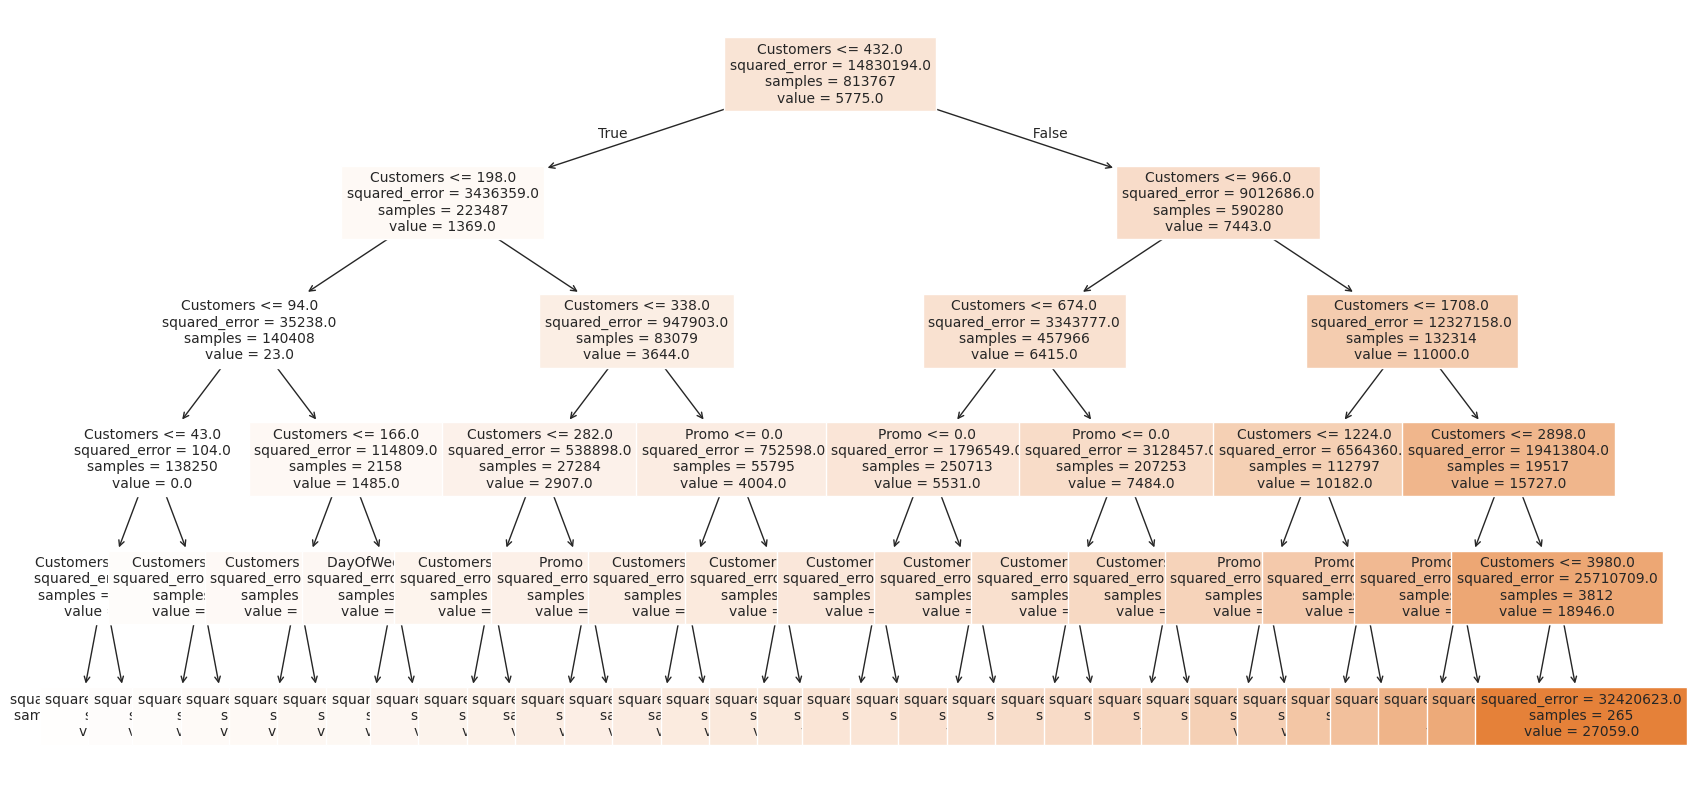

In [63]:
#Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=X.columns,
          filled=True,
          fontsize=10,
          precision=0)
plt.show()

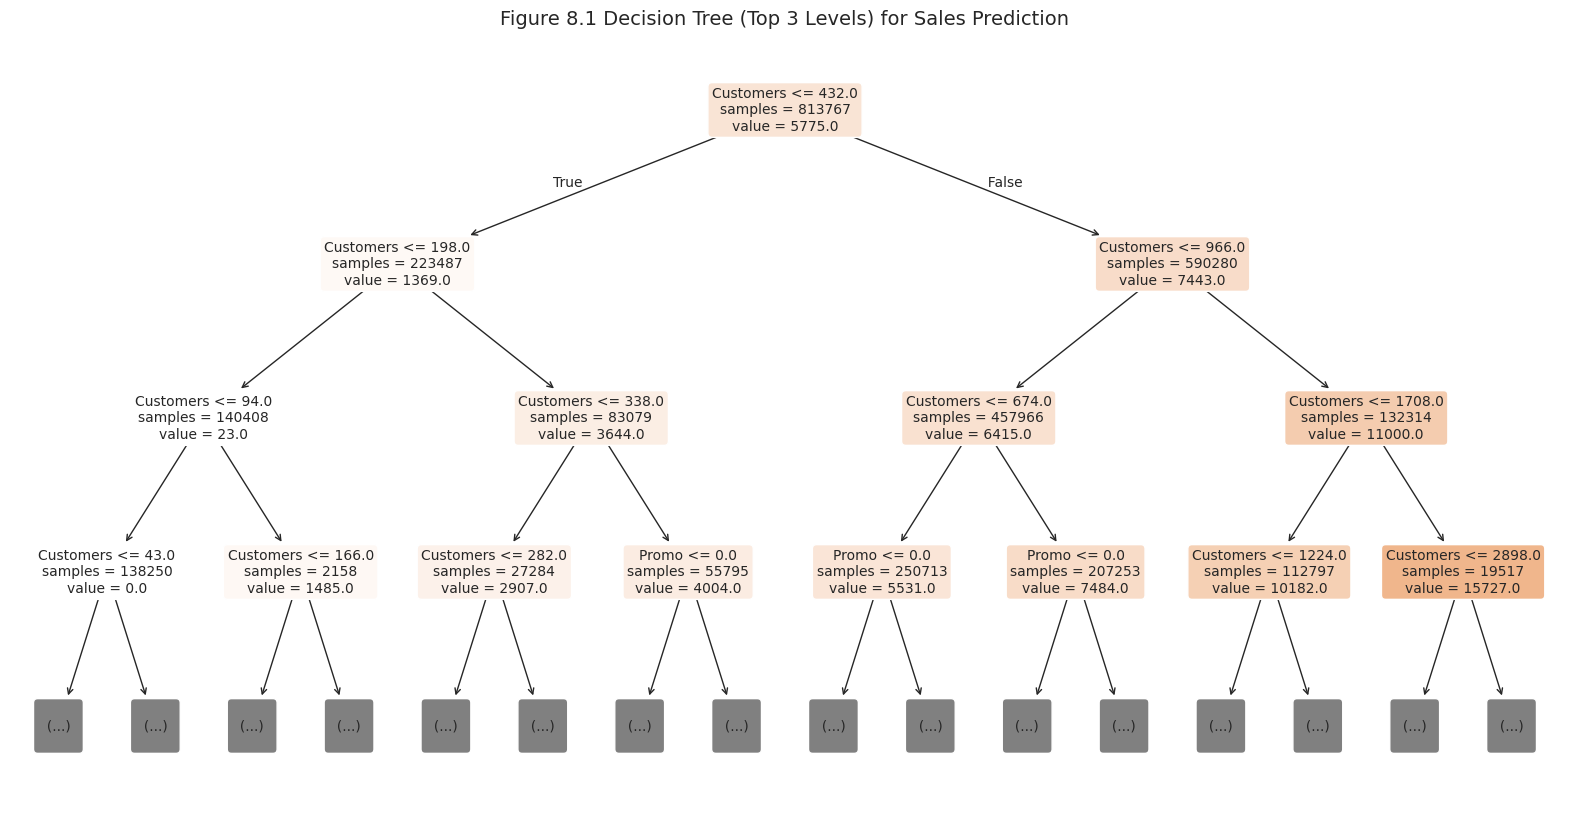

In [64]:
plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=X.columns,
          filled=True,
          fontsize=10,
          impurity=False,
          proportion=False,
          rounded=True,
          max_depth=3,
          precision=0)
plt.title("Figure 8.1 Decision Tree (Top 3 Levels) for Sales Prediction", fontsize=14)
plt.show()

####Purpose of the chart
Figure 8.1 visualizes the top three levels of the Decision Tree model trained to predict Rossmann store sales. It illustrates how the model splits the data based on key features such as the number of customers and promotions.

####Relevance to research question
Our research question focuses on identifying the main factors that drive sales performance. By showing the splitting criteria, this tree directly connects customer numbers, promotions, and store conditions to variations in sales.
####Key findings
The first and most important split is on the number of customers, which strongly determines sales volume.

Subsequent splits involve additional thresholds of customers and promotion status, showing that promotions further increase sales within customer groups.

Day of the week and holidays appear deeper in the tree but are less influential compared to customer numbers and promotions.
####Why this finding is important
These findings highlight that customer traffic and promotions are the dominant drivers of sales. This is important for managers because it shows that sales forecasting should prioritize predicting customer volume and carefully planning promotions, which aligns with the project’s goal of identifying actionable levers to improve store performance.